In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip -q "/content/drive/MyDrive/prepared_dataset.zip" -d /content

In [4]:
import os
print(os.listdir("/content/kaggle/working/dataset"))

['labels', 'images']


In [5]:
yaml_content = """
path: /content/kaggle/working/dataset
train: images/train
val: images/train

nc: 14

names:
  0: Aortic enlargement
  1: Atelectasis
  2: Calcification
  3: Cardiomegaly
  4: Consolidation
  5: ILD
  6: Infiltration
  7: Lung Opacity
  8: Nodule/Mass
  9: Other lesion
  10: Pleural effusion
  11: Pleural thickening
  12: Pneumothorax
  13: Pulmonary fibrosis
"""

with open("/content/dataset.yaml", "w") as f:
    f.write(yaml_content)

print("New dataset.yaml created for Colab ✅")

New dataset.yaml created for Colab ✅


In [6]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.2 MB/s eta 0:00:00


In [9]:
from ultralytics import YOLO

# Load lightweight pretrained model
model = YOLO("yolov8n.pt")

# Start training
model.train(
    data="/content/dataset.yaml",
    epochs=15,
    imgsz=1024,
    batch=8,
    device=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, i

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ba4968c5520>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.0

In [13]:
from ultralytics import YOLO

# Load your trained model
model = YOLO("/content/runs/detect/train/weights/best.pt")

print("Model loaded successfully ✅")

Model loaded successfully ✅


In [15]:
import os
import random

# Path to your images
image_folder = "/content/kaggle/working/dataset/images/train"

# Pick one random image
sample_image = random.choice(os.listdir(image_folder))

sample_path = os.path.join(image_folder, sample_image)

print("Testing on:", sample_path)

Testing on: /content/kaggle/working/dataset/images/train/2072cdb6aab12d25059bb55e7d832290.png



image 1/1 /content/kaggle/working/dataset/images/train/2072cdb6aab12d25059bb55e7d832290.png: 1024x1024 1 Aortic enlargement, 1 Cardiomegaly, 13.2ms
Speed: 3.8ms preprocess, 13.2ms inference, 1.5ms postprocess per image at shape (1, 3, 1024, 1024)


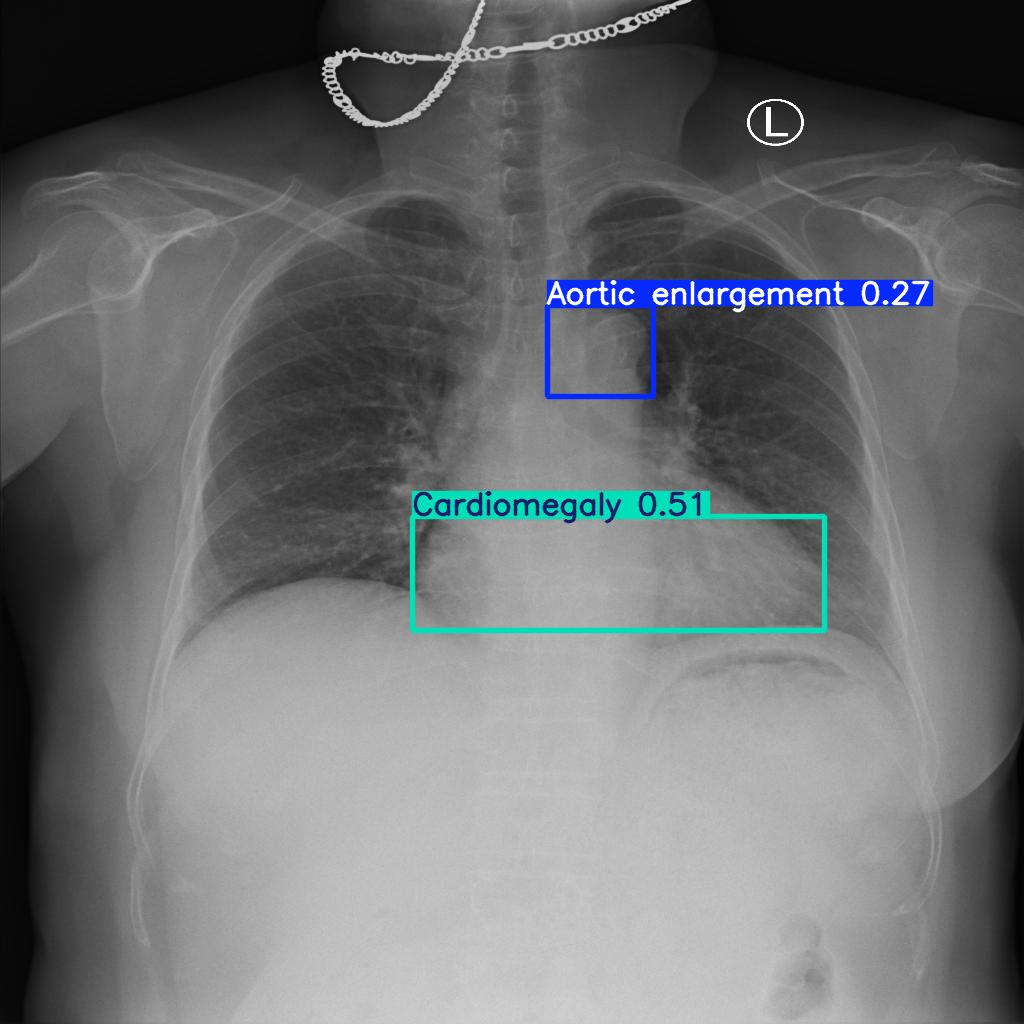

In [16]:
results = model(sample_path, conf=0.25)

# Show result
results[0].show()